In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [32]:
import os

os.makedirs("output", exist_ok=True)

print("Output folder created successfully!")

Output folder created successfully!


In [3]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trader Data Shape :", trades.shape)
print("Sentiment Shape :", sentiment.shape)

Trader Data Shape : (211224, 16)
Sentiment Shape : (2644, 4)


In [4]:
print("Trader Data")
display(trades.head())

print("Sentiment Data")
display(sentiment.head())

Trader Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Sentiment Data


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
print("Trader Dataset")

print("Rows :", trades.shape[0])
print("Columns :", trades.shape[1])

print()

print("Sentiment Dataset")

print("Rows :", sentiment.shape[0])
print("Columns :", sentiment.shape[1])

Trader Dataset
Rows : 211224
Columns : 16

Sentiment Dataset
Rows : 2644
Columns : 4


In [6]:
print("Trader Dataset Missing Values")

display(trades.isnull().sum())

print()

print("Sentiment Dataset Missing Values")

display(sentiment.isnull().sum())

Trader Dataset Missing Values


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Sentiment Dataset Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [7]:
print("Trader Duplicate Rows")

print(trades.duplicated().sum())

print()

print("Sentiment Duplicate Rows")

print(sentiment.duplicated().sum())

Trader Duplicate Rows
0

Sentiment Duplicate Rows
0


In [8]:
print("Trader Data Types")

display(trades.dtypes)

print()

print("Sentiment Data Types")

display(sentiment.dtypes)

Trader Data Types


Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


Sentiment Data Types


timestamp         int64
value             int64
classification      str
date                str
dtype: object

In [9]:
print("Trader Dataset Columns")
print(trades.columns.tolist())

print("\nSentiment Dataset Columns")
print(sentiment.columns.tolist())

Trader Dataset Columns
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sentiment Dataset Columns
['timestamp', 'value', 'classification', 'date']


In [10]:
# Convert trader timestamp into date only
trades["Date"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
).dt.date

# Convert sentiment date
sentiment["Date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

print("Dates Converted Successfully")

Dates Converted Successfully


In [11]:
print("Trader Dates")

display(trades[["Timestamp IST","Date"]].head())

print()

print("Sentiment Dates")

display(sentiment[["date","Date"]].head())

Trader Dates


,Timestamp IST,Date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02



Sentiment Dates


,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [12]:
merged = pd.merge(
    trades,
    sentiment,
    on="Date",
    how="left"
)

print("Merged Shape :", merged.shape)

display(merged.head())

Merged Shape : (211224, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [13]:
daily_pnl = merged.groupby(["Date", "Account"]).agg(
    Daily_PnL=("Closed PnL", "sum")
).reset_index()

print("Daily PnL Table")

display(daily_pnl.head())

Daily PnL Table


,Date,Account,Daily_PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [14]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = merged.groupby("Account").agg(
    Total_Trades=("Win", "count"),
    Winning_Trades=("Win", "sum")
)

win_rate["Win_Rate"] = (
    win_rate["Winning_Trades"] /
    win_rate["Total_Trades"]
) * 100

display(win_rate.head())

,Total_Trades,Winning_Trades,Win_Rate
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1373,35.961236
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,3223,44.271978
0x271b280974205ca63b716753467d5a371de622ab,3809,1150,30.191651
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,5838,43.858463
0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1684,51.991355


In [15]:
avg_trade = merged.groupby("Account").agg(
    Average_Trade_Size=("Size USD", "mean")
)

display(avg_trade.head())

,Average_Trade_Size
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
0x271b280974205ca63b716753467d5a371de622ab,8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [16]:
trades_per_day = merged.groupby("Date").size().reset_index(name="Trades")

display(trades_per_day.head())

,Date,Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [17]:
long_short = merged["Side"].value_counts()

display(long_short)

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [18]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date', 'Win']


In [19]:
pnl_sentiment = merged.groupby("classification")["Closed PnL"].mean().sort_values()

display(pnl_sentiment)

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64

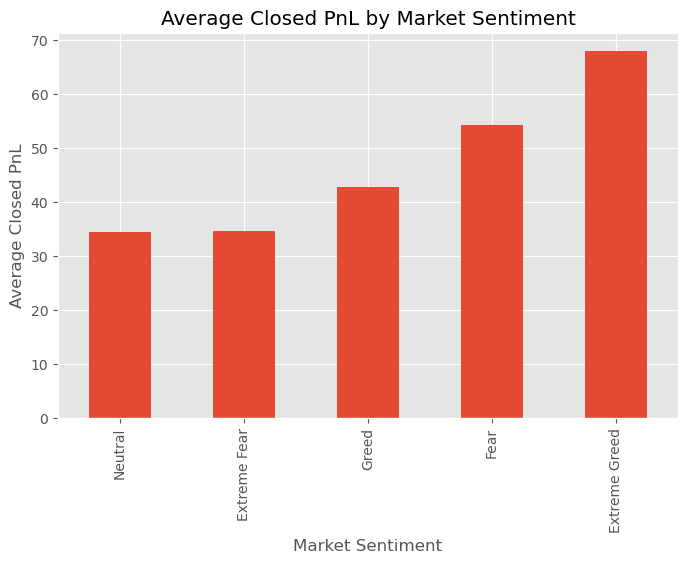

In [33]:
plt.figure(figsize=(8,5))

pnl_sentiment.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.savefig("output/chart1_average_pnl_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

In [21]:
trade_count = merged["classification"].value_counts()

display(trade_count)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

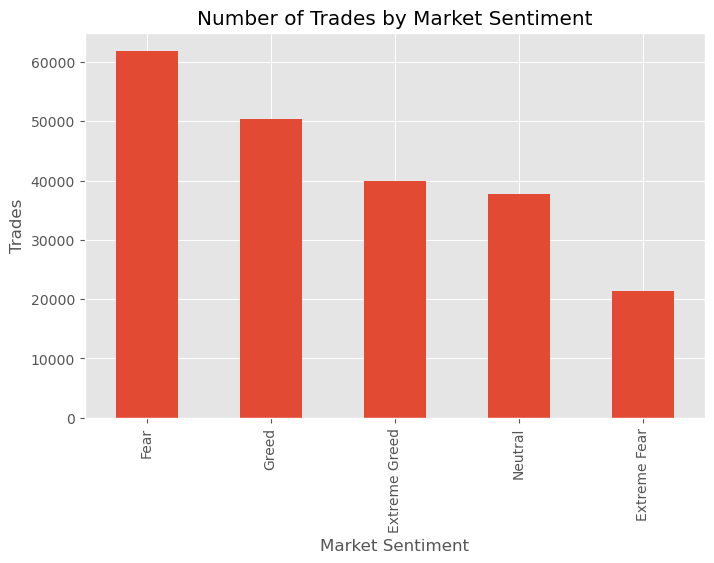

In [35]:
plt.figure(figsize=(8,5))

trade_count.plot(kind="bar")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades")
plt.savefig("output/chart2_trade_count_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

In [23]:
buy_sell = merged.groupby(["classification","Side"]).size().unstack(fill_value=0)

display(buy_sell)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


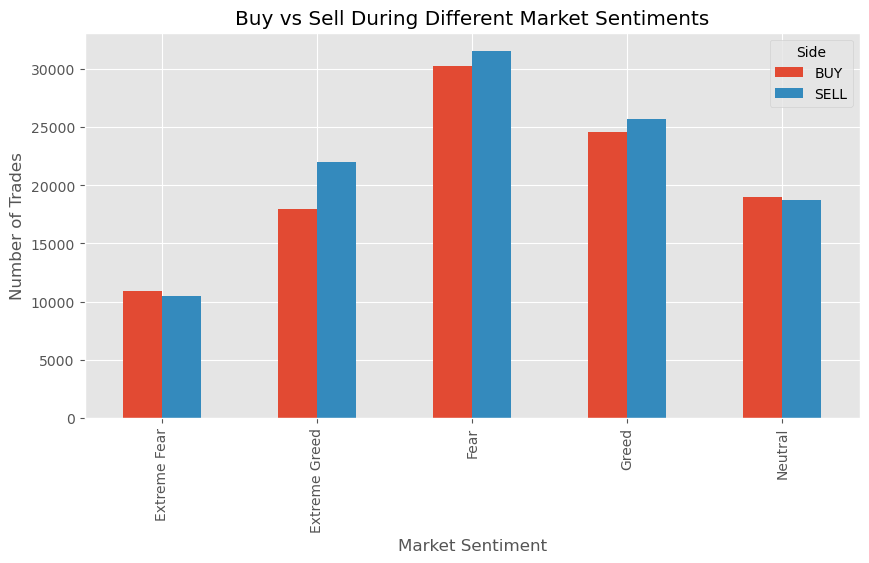

In [36]:
buy_sell.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Buy vs Sell During Different Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.savefig("output/chart3_buy_vs_sell.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

In [25]:
top_days = merged.groupby("Date")["Closed PnL"].sum()

top_days = top_days.sort_values(ascending=False)

display(top_days.head(10))

Date
2025-03-03    616413.032233
2024-12-12    599151.795008
2025-02-04    416876.888120
2025-04-12    410419.694533
2024-12-22    352197.163973
2025-02-03    348871.326269
2024-12-11    319051.554217
2024-12-04    292891.815021
2025-03-12    288105.984215
2025-03-05    269328.365917
Name: Closed PnL, dtype: float64

In [26]:
account_summary = merged.groupby("Account").agg(
    Total_PnL=("Closed PnL","sum"),
    Total_Trades=("Account","count"),
    Avg_Trade_Size=("Size USD","mean")
).reset_index()

display(account_summary.head())

,Account,Total_PnL,Total_Trades,Avg_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,3138.894782


In [27]:
account_summary["Trader_Type"] = account_summary["Total_Trades"].apply(
    lambda x: "Frequent Trader" if x > account_summary["Total_Trades"].median()
    else "Infrequent Trader"
)

display(account_summary.head())

,Account,Total_PnL,Total_Trades,Avg_Trade_Size,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,8893.000898,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,3138.894782,Infrequent Trader


In [28]:
account_summary["Profit_Category"] = account_summary["Total_PnL"].apply(
    lambda x: "High Profit" if x > account_summary["Total_PnL"].median()
    else "Low Profit"
)

display(account_summary.head())

,Account,Total_PnL,Total_Trades,Avg_Trade_Size,Trader_Type,Profit_Category
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734,Frequent Trader,High Profit
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327,Frequent Trader,Low Profit
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,8893.000898,Frequent Trader,Low Profit
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933,Frequent Trader,High Profit
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,3138.894782,Infrequent Trader,High Profit


In [29]:
segment_summary = account_summary.groupby("Trader_Type").agg(
    Average_PnL=("Total_PnL","mean"),
    Average_Trades=("Total_Trades","mean")
)

display(segment_summary)

,Average_PnL,Average_Trades
Trader_Type,,
Frequent Trader,496527.661215,11684.8125
Infrequent Trader,147032.272750,1516.6875


In [37]:
top_days.head(10).to_csv("output/top_10_profitable_days.csv")

# Key Insights

### Insight 1
Average Closed PnL is highest during Extreme Greed market conditions and lowest during Neutral market conditions.

### Insight 2
Fear days have the highest number of trades, indicating that traders are more active during fearful market conditions.

### Insight 3
SELL trades slightly exceed BUY trades in most market conditions except Neutral, suggesting a mild preference for short positions.

# Strategy Recommendations

## Strategy 1

During Extreme Greed conditions, traders can consider increasing exposure carefully because average profitability is highest.

## Strategy 2

During Fear conditions, traders should avoid excessive trading despite high market activity and instead focus on high-quality trade setups.

# Methodology

- Loaded both datasets.
- Checked rows, columns, missing values and duplicates.
- Converted timestamps into daily dates.
- Merged trader and sentiment datasets.
- Calculated Daily PnL, Win Rate, Average Trade Size, Trade Count and Buy/Sell Ratio.
- Created trader segments.
- Generated charts for sentiment analysis.
- Derived actionable insights and strategy recommendations.